In [1]:
import pandas as pd

In [2]:
train = pd.read_csv("/content/train 2.csv")
stores = pd.read_csv("/content/stores.csv")
features = pd.read_csv("/content/features.csv")

In [3]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
train['Date'] = pd.to_datetime(train['Date'])

In [5]:
train = train.sort_values('Date')

In [6]:
train.set_index('Date',inplace=True)

In [7]:
monthly_sales = train["Weekly_Sales"].resample("M").sum()

/tmp/ipython-input-3250090049.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = train["Weekly_Sales"].resample("M").sum()


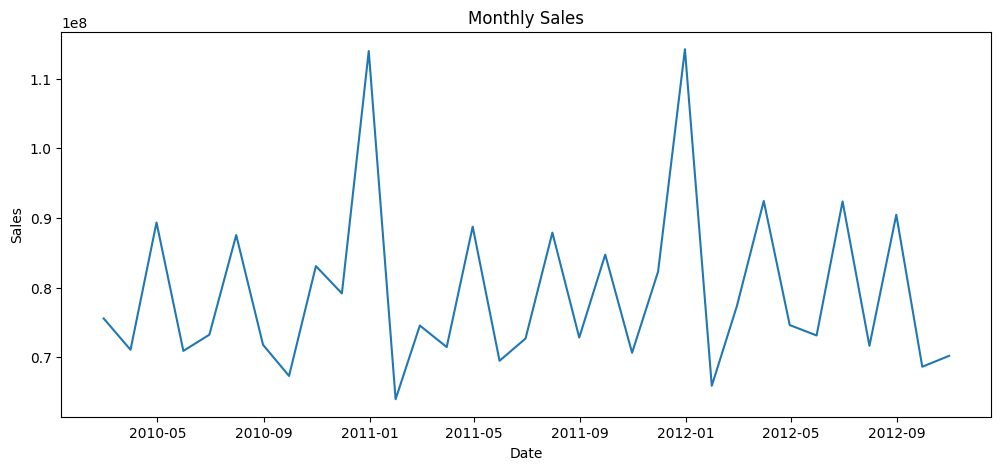

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(monthly_sales)
plt.title("Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [9]:
rolling_mean = monthly_sales.rolling(12).mean()
rolling_std = monthly_sales.rolling(12).std()

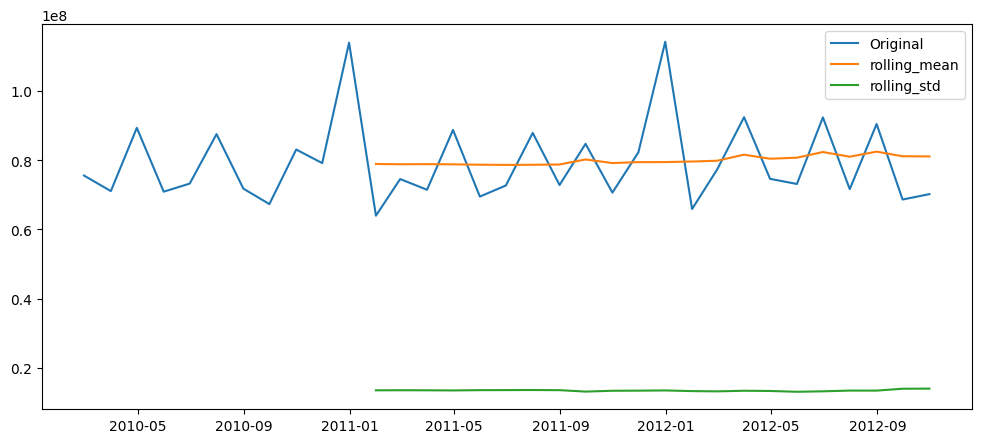

In [13]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales,label="Original")
plt.plot(rolling_mean,label="rolling_mean")
plt.plot(rolling_std,label="rolling_std")
plt.legend()
plt.show()

In [14]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales.dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -5.8042883583889715
p-value: 4.554590023462516e-07


In [15]:
sales_diff = monthly_sales.diff().dropna()


In [16]:
adfuller(sales_diff)[1]


np.float64(0.010296730548469546)

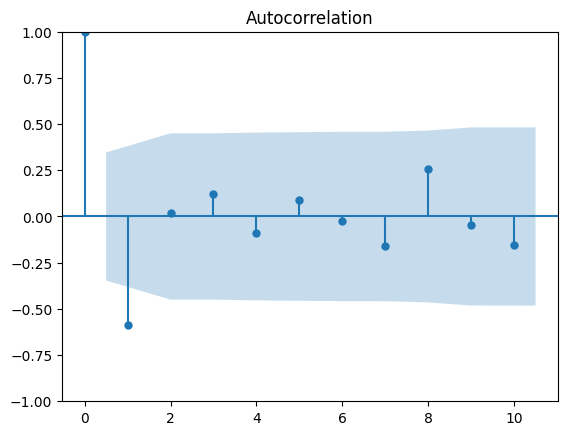

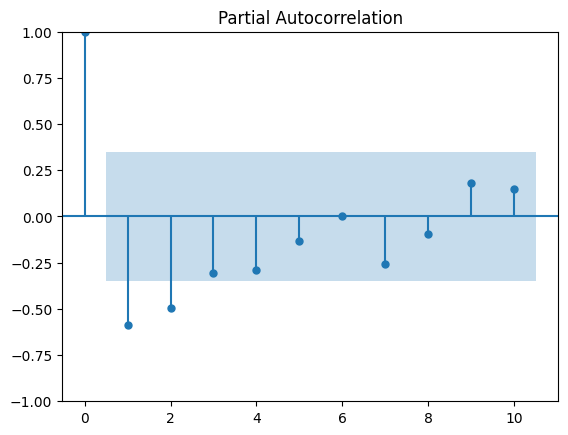

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(sales_diff, lags=10)
plot_pacf(sales_diff, lags=10)
plt.show()

In [20]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(monthly_sales, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                   33
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -577.007
Date:                Fri, 20 Feb 2026   AIC                           1160.015
Time:                        17:46:21   BIC                           1164.412
Sample:                    02-28-2010   HQIC                          1161.472
                         - 10-31-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0377      0.159     -0.236      0.813      -0.350       0.275
ma.L1         -0.7648      0.138     -5.548      0.000      -1.035      -0.495
sigma2      1.972e+14      5e-17   3.94e+30      0.0

In [21]:
forecast = model_fit.forecast(steps=12)


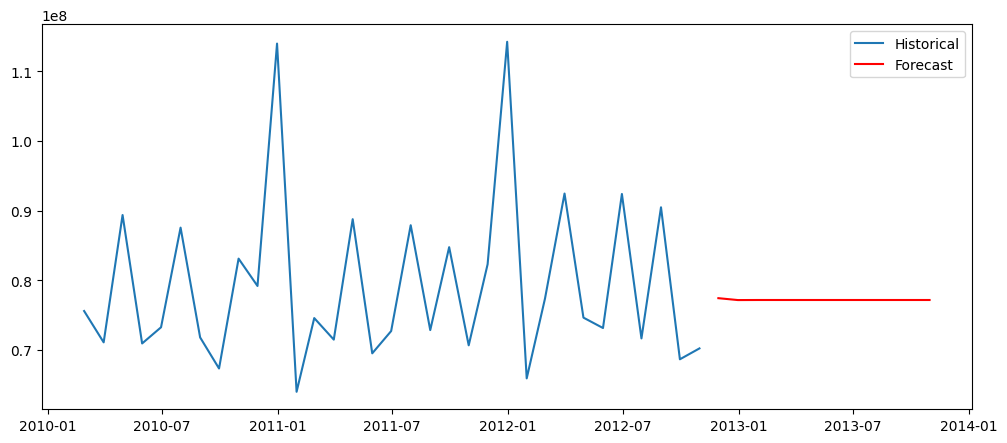

In [22]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales, label='Historical')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.show()


In [23]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(
    monthly_sales,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima.fit()
sarima_fit.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                       Weekly_Sales   No. Observations:                   33
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -357.745
Date:                            Fri, 20 Feb 2026   AIC                            725.490
Time:                                    17:47:03   BIC                            730.468
Sample:                                02-28-2010   HQIC                           726.462
                                     - 10-31-2012                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4681      0.332     -1.412      0.158      -1.118       0.182
ma.L1         -0.0480      0.271     -0.177      0.859      -0.579       0.483
ar.S.L12       0.4416      0.286      1.545      0.122      -0.119       1.002
ma.S.L12      -1.0000      0.487     -2.055      0.040      -1.954      -0.046
sigma2       1.44e+14   3.38e-15   4.26e+28      0.000    1.44e+14    1.44e+14
===================================================================================
Ljung-Box (L1) (Q):                   6.27   Jarque-Bera (JB):                 0.91
Prob(Q):                              0.01   Prob(JB):                         0.63
Heteroskedasticity (H):               2.68   Skew:                             0.08
Prob(H) (two-sided):                  0.22   Kurtosis:                         1.97
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 8.18e+44. Standard errors may be unstable.
"""

In [25]:
!pip install pandas statsmodels scikit-learn joblib



In [27]:
import joblib

# Save the existing model_fit as .pkl
joblib.dump(model_fit, "arima_model.pkl")

print("ARIMA model saved as arima_model.pkl")

ARIMA model saved as arima_model.pkl


In [28]:
import joblib

# Save the SARIMAX model
joblib.dump(sarima_fit, "sarimax_model.pkl")

print("SARIMAX model saved as 'sarimax_model.pkl'")

SARIMAX model saved as 'sarimax_model.pkl'


A `requirements.txt` file has been created in your Colab environment. You can view its content or download it in the same way as the `.pkl` files.

You can now find `arima_model.pkl` and `sarimax_model.pkl` in your Colab environment. You can download them by clicking on the folder icon on the left panel, navigating to the files, right-clicking on them, and selecting 'Download'.